# Makemore (part 2)

This notebook is based on [this video](https://www.youtube.com/watch?v=TCH_1BHY58I)

### Imports

In [125]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
%matplotlib inline

### Get data

In [126]:
data_url = "https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"
data_filename = "names.txt"

!wget -q -nc -O {data_filename} {data_url}

In [127]:
words = open(data_filename, 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [128]:
len(words)

32033

In [129]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [130]:
def build_dataset(words, block_size=3):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            # print(''.join(itos[i] for i in context), '->', itos[idx])
            context = context[1:] + [idx]  # slide window forward by one character
    return torch.tensor(X), torch.tensor(Y)

In [131]:
X, Y = build_dataset(words[:5])

In [132]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

### First approach to build NN

In [133]:
# lookup table (for embeddings)
C = torch.randn((27, 2))

In [134]:
C[5]

tensor([2.5874, 0.8396])

In [135]:
# using one-hot is the same if we just get values by indexes
idx = F.one_hot(torch.tensor(5), num_classes=27).float()
idx @ C

tensor([2.5874, 0.8396])

In [136]:
emb = C[X]
emb.shape, X.shape

(torch.Size([32, 3, 2]), torch.Size([32, 3]))

In [137]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [138]:
# we need to rearrange emb[32, 3, 2] tensor to get [32, 6] tensor, so we can multiply it by W1[6, 100]
# there are several ways to do this, the most efficient way is to use view method
a = torch.arange(18)
a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [139]:
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [140]:
emb.view(32, 6)

tensor([[-0.7794,  1.0007, -0.7794,  1.0007, -0.7794,  1.0007],
        [-0.7794,  1.0007, -0.7794,  1.0007,  2.5874,  0.8396],
        [-0.7794,  1.0007,  2.5874,  0.8396,  1.8374, -0.3710],
        [ 2.5874,  0.8396,  1.8374, -0.3710,  1.8374, -0.3710],
        [ 1.8374, -0.3710,  1.8374, -0.3710, -0.2341, -1.2554],
        [-0.7794,  1.0007, -0.7794,  1.0007, -0.7794,  1.0007],
        [-0.7794,  1.0007, -0.7794,  1.0007, -0.3368, -0.1408],
        [-0.7794,  1.0007, -0.3368, -0.1408, -0.4479,  1.3902],
        [-0.3368, -0.1408, -0.4479,  1.3902, -1.6561,  0.0649],
        [-0.4479,  1.3902, -1.6561,  0.0649,  1.0770, -0.4014],
        [-1.6561,  0.0649,  1.0770, -0.4014, -1.6561,  0.0649],
        [ 1.0770, -0.4014, -1.6561,  0.0649, -0.2341, -1.2554],
        [-0.7794,  1.0007, -0.7794,  1.0007, -0.7794,  1.0007],
        [-0.7794,  1.0007, -0.7794,  1.0007, -0.2341, -1.2554],
        [-0.7794,  1.0007, -0.2341, -1.2554,  1.0770, -0.4014],
        [-0.2341, -1.2554,  1.0770, -0.4

In [141]:
h = emb.view(-1, 6) @ W1 + b1  # -1 tells view to infer this dimension automatically

In [142]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [143]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [144]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([32, 27])

In [145]:
loss = -prob[torch.arange(32), Y].log().mean()

In [147]:
loss  # we recieve here inf, so let's use cross_entropy instead of step-by-step calculations

tensor(inf)

### Second approach

In [148]:
# refactor into reusable functions to support hyperparameter experimentation
g = torch.Generator().manual_seed(2147483647)
random.seed(42)
def create_nn(emb_size=10, hidden_layer_size=200):
    C = torch.randn((27, emb_size), generator=g)
    W1 = torch.randn((3*emb_size, hidden_layer_size), generator=g)
    b1 = torch.randn(hidden_layer_size, generator=g)
    W2 = torch.randn((hidden_layer_size, 27), generator=g)
    b2 = torch.randn(27, generator=g)
    parameters = [C, W1, b1, W2, b2]
    for p in parameters:
        p.requires_grad = True
    return parameters

In [149]:
parameters = create_nn()
sum(p.nelement() for p in parameters)  # number of parameters in total

11897

In [150]:
parameters[0].shape[1]

10

In [151]:
def forward(X, parameters):
    [C, W1, b1, W2, b2] = parameters
    emb_size = C.shape[1]
    emb = C[X]
    h = torch.tanh(emb.view(-1, 3*emb_size) @ W1 + b1)
    logits = h @ W2 + b2
    return logits

In [152]:
def train(X, Y, parameters, learning_rate=0.1, batch_size=32):
    idx = torch.randint(0, X.shape[0], (batch_size,))
    X_batch = X[idx]
    Y_batch = Y[idx]
    logits = forward(X_batch, parameters)
    loss = F.cross_entropy(logits, Y_batch)
    # backward
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -learning_rate * p.grad
    return loss    

In [153]:
train(X, Y, parameters)

tensor(30.2429, grad_fn=<NllLossBackward0>)

In [154]:
# split the dataset into training, validation and test sets
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [155]:
nn = create_nn()
stepi = []
lossi = []
for i in range(200000):
    lr = 0.1 if i < 100000 else 0.01
    loss = train(Xtr, Ytr, nn, lr)
    stepi.append(i)
    lossi.append(loss.log10().item())

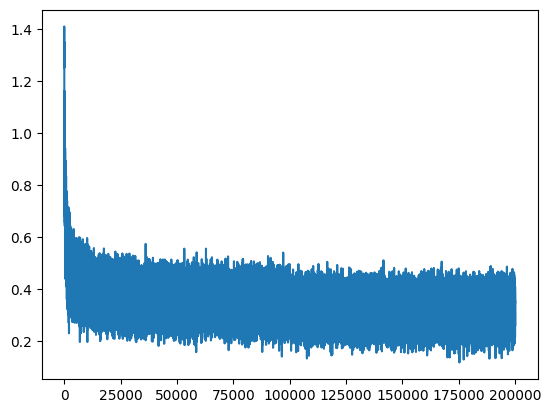

In [156]:
plt.plot(stepi, lossi)

In [157]:
logits = forward(Xval, nn)
loss = F.cross_entropy(logits, Yval)
loss

tensor(2.1699, grad_fn=<NllLossBackward0>)

In [158]:
# sample from the model
def samples(parameters, n=20):
    g = torch.Generator().manual_seed(2147483647 + 10)
    block_size = 3
    for _ in range(n):
        out = []
        context = [0] * block_size # initialize with all ...
        while True:
            logits = forward(torch.tensor([context]), parameters)
            probs = F.softmax(logits, dim=1)
            idx = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [idx]
            out.append(idx)
            if idx == 0:
                break
        print(''.join(itos[i] for i in out))

In [159]:
samples(nn)

carlah.
quillivi.
kimri.
reety.
skael.
keja.
hutna.
perric.
kaeli.
ner.
kia.
chaiir.
kaleigh.
ham.
porriquint.
suline.
liveni.
watell.
dearyn.
kar.


In [160]:
# visualize the 10-dim embedding vectors by projecting to 2D with PCA
C = nn[0]
C.shape

torch.Size([27, 10])

In [161]:
C_centered = C - C.mean(dim=0)
U, S, V = torch.pca_lowrank(C_centered, q=2)
C_2d = C_centered @ V[:, :2]
C_2d.shape

torch.Size([27, 2])

In [162]:
def draw_emb(Emb):
    plt.figure(figsize=(8,8))
    plt.scatter(Emb[:,0].data, Emb[:,1].data, s=200)
    for i in range(Emb.shape[0]):
        plt.text(Emb[i,0].item(), Emb[i,1].item(), itos[i], ha="center", va="center", color='white')
    plt.grid('minor')

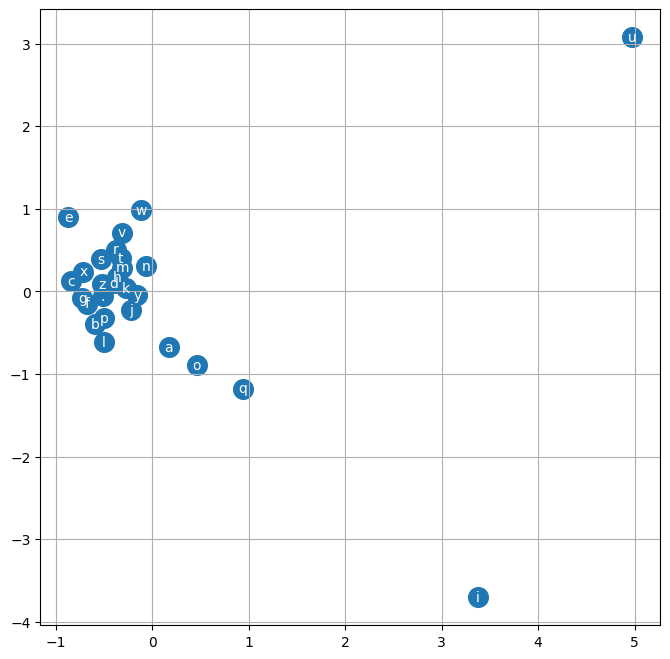

In [163]:
draw_emb(C_2d)

In [164]:
nn2 = create_nn(emb_size=2, hidden_layer_size=100)
for i in range(100000):
    lr = 0.1 if i < 50000 else 0.01
    loss = train(Xtr, Ytr, nn2, lr)

In [165]:
loss

tensor(2.0411, grad_fn=<NllLossBackward0>)

In [166]:
samples(nn2, n=50)

careah.
amelle.
khi.
mrix.
taty.
salan.
kejrahnen.
delyah.
jarqui.
nerania.
chaiir.
kaleig.
dham.
por.
desinn.
sroilea.
jadbi.
wazero.
dearyxi.
jaceeni.
sai.
edaedi.
abetteley.
fra.
arae.
bylahisya.
pamiosozery.
ojeni.
kairaen.
ken.
adlieo.
zom.
sriora.
kryne.
ammalianray.
kaenaloqv.
ruy.
bra.
adee.
tithab.
moll.
drayleisla.
kercon.
azinenadhe.
kai.
sayah.
zamdeen.
bry.
adylon.
roa.


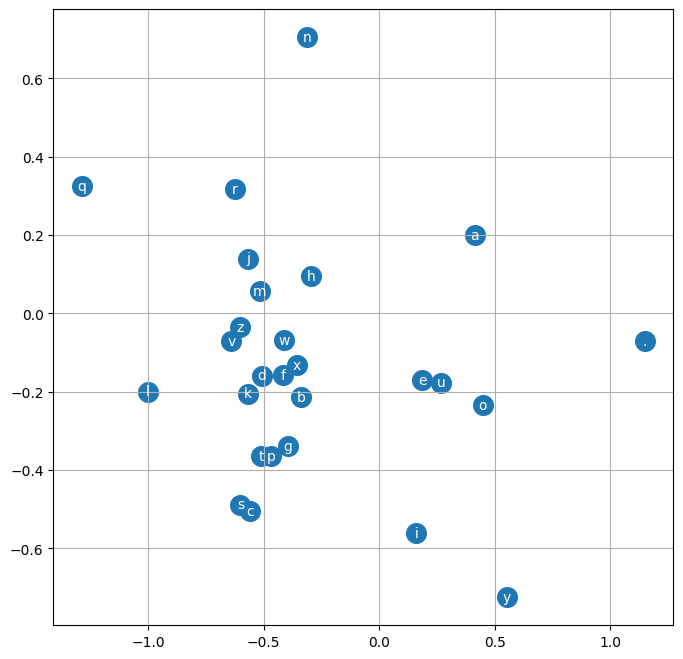

In [167]:
draw_emb(nn2[0])